## Loading Dataset

In [2]:
import pandas as pd

df = pd.read_csv('Dataset.csv')
print(f"\nDataframe Shape: {df.shape}\n")
df.head(10)


Dataframe Shape: (1255, 9)



,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001.0,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001.0,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001.0,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001.0,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001.0,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up
5,2001.0,0.213,0.614,-0.623,1.032,0.959,1.3491,1.392,Up
6,2001.0,1.392,0.213,0.614,-0.623,1.032,1.4450,-0.403,Down
7,2001.0,-0.403,1.392,0.213,0.614,-0.623,1.4078,0.027,Up
8,2001.0,0.027,-0.403,1.392,0.213,0.614,1.1640,1.303,Up
9,2001.0,1.303,0.027,-0.403,1.392,0.213,1.2326,0.287,Up


## Dataset Info

In [3]:
def print_head_transposed(data_frame_in):
    print(f"\n#####*****----- DATA FRAME - HEAD TRANSPOSED -----*****#####\n\n{data_frame_in.head(6).T}\n")

# ----------------- Statistical Summary of the Dataset -----------------
def print_pandas_describe(data_frame_in):
    print(f"\n#####*****----- DATA FRAME - PANDAS DESCRIBE TRANSPOSED -----*****#####\n\n{data_frame_in.describe(include='all').T}\n")


# ----------------- Customized Funcion to Describe the Data Frame -----------------
def customised_describe(data_frame_in): 
    print(f"\n#####*****----- DATA FRAME - CUSTOMIZED DESCRIBE - J.S. ---*****#####") 
    
    #------- Data Info -------
    features = []
    dtypes = []
    count = []
    unique = []
    missing = []
    duplicates = []
    for i in data_frame_in.columns:
        features.append(i)
        dtypes.append(data_frame_in[i].dtype)
        count.append(len(data_frame_in[i]))
        unique.append(len(data_frame_in[i].unique()))
        duplicates.append(data_frame_in[i].duplicated().sum()) # Count how many duplicate rows exist
        missing.append(data_frame_in[i].isnull().sum())
    print(f"\n{pd.DataFrame({'FEATURES': features,' DATA_TYPE': dtypes,'COUNT': count,'UNIQUE': unique, 'DUPLICATES': duplicates, 'MISSING': missing})}")

    #------- Duplicates -------
    num_duplicate_rows = df.duplicated().sum()
    print(f"\nNumber of duplicate rows: {num_duplicate_rows}")
    if(num_duplicate_rows):
        print(f"\nDuplicated rows:")
        print(df[df.duplicated(keep=False)])

    #------- Missing values -------
    num_missing_values = df.isnull().sum().sum()
    print(f"\nTotal missing values: {num_missing_values}")
    if(num_missing_values):
        print(f"\nColumns with missing values: {df.columns[df.isnull().any()].tolist()}") # Colunms with missing values
        pd.set_option('display.max_rows', None)  # Set to show all rows
        print(f"\nRows with missing values:\n{df[df.isnull().any(axis=1)]}") # Show all rows with any missing values
        pd.reset_option('display.max_rows')  # Reset display 
# ------------------------------------------------------------------------------------------

print_head_transposed(df)
print_pandas_describe(df) # Summary of the dataset - Pandas
customised_describe(df) # Summary of the dataset - Customized - Jonas


#####*****----- DATA FRAME - HEAD TRANSPOSED -----*****#####

                0       1       2       3       4       5
Year       2001.0  2001.0  2001.0  2001.0  2001.0  2001.0
Lag1        0.381   0.959   1.032  -0.623   0.614   0.213
Lag2       -0.192   0.381   0.959   1.032  -0.623   0.614
Lag3       -2.624  -0.192   0.381   0.959   1.032  -0.623
Lag4       -1.055  -2.624  -0.192   0.381   0.959   1.032
Lag5         5.01  -1.055  -2.624  -0.192   0.381   0.959
Volume     1.1913  1.2965  1.4112   1.276  1.2057  1.3491
Today       0.959   1.032  -0.623   0.614   0.213   1.392
Direction      Up      Up    Down      Up      Up      Up


#####*****----- DATA FRAME - PANDAS DESCRIBE TRANSPOSED -----*****#####

            count unique  top freq         mean       std      min     25%  \
Year       1254.0    NaN  NaN  NaN  2003.015949  1.407335   2001.0  2002.0   
Lag1       1255.0    NaN  NaN  NaN     0.003095  1.137445   -4.922   -0.64   
Lag2       1253.0    NaN  NaN  NaN     0.002291 

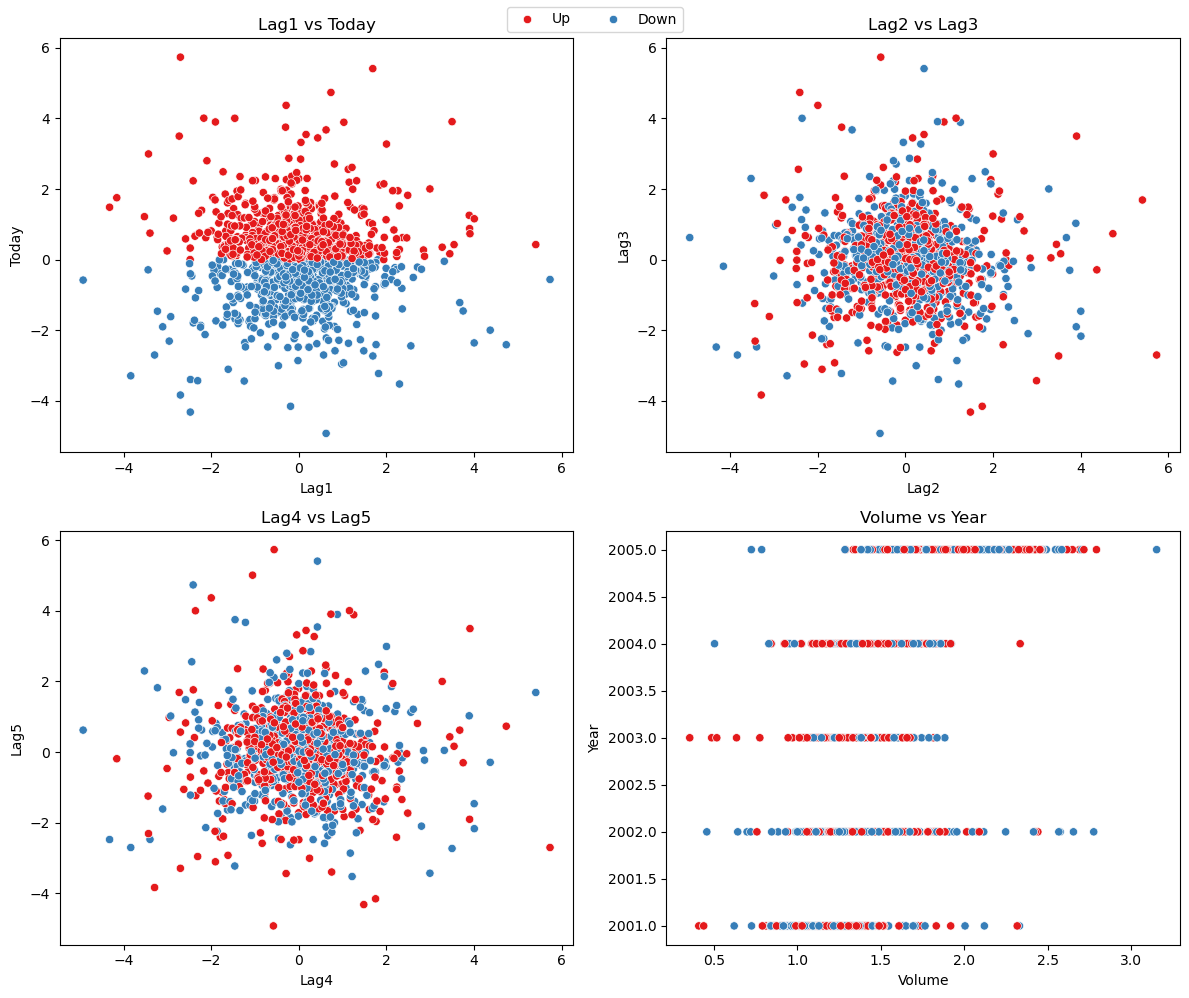

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------- Plot pairs of features, coloring the points based on the 'Direction' column ---------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(data=df, x='Lag1', y='Today', hue='Direction', palette='Set1', ax=axes[0, 0])
axes[0, 0].set_title("Lag1 vs Today")
sns.scatterplot(data=df, x='Lag2', y='Lag3', hue='Direction', palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title("Lag2 vs Lag3")
sns.scatterplot(data=df, x='Lag4', y='Lag5', hue='Direction', palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title("Lag4 vs Lag5")
sns.scatterplot(data=df, x='Volume', y='Year', hue='Direction', palette='Set1', ax=axes[1, 1])
axes[1, 1].set_title("Volume vs Year")

handles, labels = axes[0, 0].get_legend_handles_labels() # Remove duplicate legends
for ax in axes.flat:
    ax.legend().remove()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout()
plt.show()

## Data Cleaning

In [5]:
from sklearn.impute import SimpleImputer

# -------------------- Handling Missing Values -------------------------
def replace_missing_values(data_frame_in):
   
    # ---- For numerical columns ----
    num_cols = data_frame_in.select_dtypes(include=['int64', 'float64']).columns
    if len(num_cols) > 0:
        num_imputer = SimpleImputer(strategy='mean')
        data_frame_in[num_cols] = num_imputer.fit_transform(data_frame_in[num_cols])
    
    # ---- For categorical columns ----
    cat_cols = data_frame_in.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        data_frame_in[cat_cols] = cat_imputer.fit_transform(data_frame_in[cat_cols])

    return data_frame_in
# -------------------------------------------------------------------------

df = replace_missing_values(df)

/var/folders/t1/1jdtrlw55h5_jj9k_pztw5900000gn/T/ipykernel_91545/4146893246.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data_frame_in.select_dtypes(include=['object', 'category']).columns


#### Note: As there is only 2 rows with missing values, I would normaly just drop the rows. But I wanna practice the use of Simple Imputer from sklearn.

In [6]:
# -------------------- Checking The Results -------------------------

print_pandas_describe(df) # Summary of the dataset - Pandas
customised_describe(df) # Summary of the dataset - Customized - Jonas
print(f"\nRows that had missing values:\n{df.loc[[626, 1168]]}") # Print the rows that used to have missing values


#####*****----- DATA FRAME - PANDAS DESCRIBE TRANSPOSED -----*****#####

            count unique  top freq         mean       std      min      25%  \
Year       1255.0    NaN  NaN  NaN  2003.015949  1.406774   2001.0   2002.0   
Lag1       1255.0    NaN  NaN  NaN     0.003095  1.137445   -4.922    -0.64   
Lag2       1255.0    NaN  NaN  NaN     0.002291  1.138215   -4.922   -0.639   
Lag3       1255.0    NaN  NaN  NaN     0.003424  1.142635   -4.922  -0.6405   
Lag4       1255.0    NaN  NaN  NaN     0.003414  1.139888   -4.922    -0.64   
Lag5       1255.0    NaN  NaN  NaN     0.004885  1.146724   -4.922    -0.64   
Volume     1255.0    NaN  NaN  NaN     1.478563  0.359722  0.35607  1.25825   
Today      1255.0    NaN  NaN  NaN     0.006271  1.140164   -4.922   -0.639   
Direction    1255      2   Up  652          NaN       NaN      NaN      NaN   

              50%      75%      max  
Year       2003.0   2004.0   2005.0  
Lag1        0.039   0.5965    5.733  
Lag2        0.038   0

In [7]:
# -------------------- Remove duplicates ----------------------

df = df.drop_duplicates()

# -------------------- Checking The Results ---------------------------

customised_describe(df) # Summary of the dataset - Customized - Jonas

# ----------------- Try to Print Input Rows ---------------------------
def check_row(row_index):
    if row_index in df.index:
        print(f"\nRow with index {row_index}:\n{df.loc[[row_index]]}")
    else:
        print(f"\nRow with index {row_index} does not exist.")
# ---------------------------------------------------------------------

duplicated_rows = [430, 431, 498, 499, 799, 800] # Rows that used to be duplicated
for row in duplicated_rows:
    check_row(row)


#####*****----- DATA FRAME - CUSTOMIZED DESCRIBE - J.S. ---*****#####

    FEATURES  DATA_TYPE  COUNT  UNIQUE  DUPLICATES  MISSING
0       Year    float64   1252       6        1246        0
1       Lag1    float64   1252    1044         208        0
2       Lag2    float64   1252    1046         206        0
3       Lag3    float64   1252    1045         207        0
4       Lag4    float64   1252    1045         207        0
5       Lag5    float64   1252    1044         208        0
6     Volume    float64   1252    1182          70        0
7      Today    float64   1252    1044         208        0
8  Direction        str   1252       2        1250        0

Number of duplicate rows: 0

Total missing values: 0

Row with index 430:
       Year   Lag1   Lag2   Lag3   Lag4   Lag5   Volume  Today Direction
430  2002.0 -1.461 -3.226  1.821  2.486 -1.728  1.72187  4.002        Up

Row with index 431 does not exist.

Row with index 498:
       Year   Lag1   Lag2  Lag3   Lag4   Lag5  Vol

## Label Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

## --------------- Label Encoding for Categorical Variables -------------

cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col]) # Up -> '1'   Down -> '0'

/var/folders/t1/1jdtrlw55h5_jj9k_pztw5900000gn/T/ipykernel_91545/1403333932.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


In [9]:
# -------------------- Checking The Results -------------------------

print_head_transposed(df)
customised_describe(df) # Summary of the dataset - Customized - Jonas
print(f"\nDirection (first 15 values): {df['Direction'].head(15).tolist()}")


#####*****----- DATA FRAME - HEAD TRANSPOSED -----*****#####

                   0          1          2         3          4          5
Year       2001.0000  2001.0000  2001.0000  2001.000  2001.0000  2001.0000
Lag1          0.3810     0.9590     1.0320    -0.623     0.6140     0.2130
Lag2         -0.1920     0.3810     0.9590     1.032    -0.6230     0.6140
Lag3         -2.6240    -0.1920     0.3810     0.959     1.0320    -0.6230
Lag4         -1.0550    -2.6240    -0.1920     0.381     0.9590     1.0320
Lag5          5.0100    -1.0550    -2.6240    -0.192     0.3810     0.9590
Volume        1.1913     1.2965     1.4112     1.276     1.2057     1.3491
Today         0.9590     1.0320    -0.6230     0.614     0.2130     1.3920
Direction     1.0000     1.0000     0.0000     1.000     1.0000     1.0000


#####*****----- DATA FRAME - CUSTOMIZED DESCRIBE - J.S. ---*****#####

    FEATURES  DATA_TYPE  COUNT  UNIQUE  DUPLICATES  MISSING
0       Year    float64   1252       6        1246    

## Data Pre-processing

In [10]:
# ------------------------- Splitting Dataset ------------------------------

selected_features = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']

from sklearn.model_selection import train_test_split
train_set, test_set, train_labels, test_labels = train_test_split(
                                    df[selected_features],        # Features
                                    df[['Direction']],            # Labels
                                    test_size = 0.25,             # Split ratio
                                    random_state = 1,             # Set random seed
                                    stratify = df[['Direction']]) # Randomize based on Labels

# train_set.head(3), test_set.head(3), train_labels.head(3), test_labels.head(3) # Checking data split
train_set.shape, test_set.shape, train_labels.shape, test_labels.shape # Checking data split

((939, 6), (313, 6), (939, 1), (313, 1))

## Support Vector Machine (SVM)

In [11]:
# ------------------------- Training SVM Model ------------------------------

from sklearn import svm
import warnings; warnings.filterwarnings("ignore")

clf = svm.SVC(kernel = 'linear')
clf.fit(train_set, train_labels)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
# ------------------------- SVM Model Results ------------------------------

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

predictions = clf.predict(test_set)
print(f"Accuracy:\t{accuracy_score(test_labels, predictions)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(test_labels, predictions)}")
print(f"\nClassification Report:\n{classification_report(test_labels, predictions)}")

Accuracy:	0.5207667731629393

Confusion Matrix:
[[  0 150]
 [  0 163]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       150
           1       0.52      1.00      0.68       163

    accuracy                           0.52       313
   macro avg       0.26      0.50      0.34       313
weighted avg       0.27      0.52      0.36       313



## Logistic Regression

In [13]:
# ------------------------- Training Logistic Regression Model ------------------------------

from sklearn import linear_model

log_regress = linear_model.LogisticRegression()
log_regress.fit(X = train_set, y = train_labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
# ------------------------- Logistic Regression Model Results ------------------------------

predictions = log_regress.predict(test_set)
print(f"Accuracy:\t{accuracy_score(test_labels, predictions)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(test_labels, predictions)}")
print(f"\nClassification Report:\n{classification_report(test_labels, predictions)}")

Accuracy:	0.4952076677316294

Confusion Matrix:
[[ 37 113]
 [ 45 118]]

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.25      0.32       150
           1       0.51      0.72      0.60       163

    accuracy                           0.50       313
   macro avg       0.48      0.49      0.46       313
weighted avg       0.48      0.50      0.46       313



## K Nearest Neighbor (KNN)

In [15]:
# ------------------------- Training KNN Model ------------------------------

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8) # K = 8
knn.fit(train_set, train_labels)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",8
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [16]:
# ------------------------- KNN Model Results ------------------------------

predictions = knn.predict(test_set)
print(f"Accuracy:\t{accuracy_score(test_labels, predictions)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(test_labels, predictions)}")
print(f"\nClassification Report:\n{classification_report(test_labels, predictions)}")

Accuracy:	0.48881789137380194

Confusion Matrix:
[[82 68]
 [92 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.55      0.51       150
           1       0.51      0.44      0.47       163

    accuracy                           0.49       313
   macro avg       0.49      0.49      0.49       313
weighted avg       0.49      0.49      0.49       313



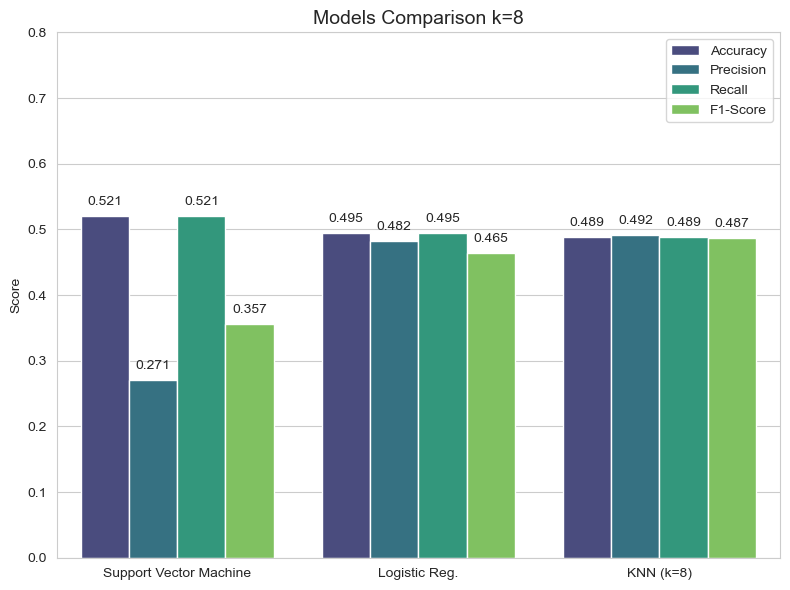

In [17]:
from sklearn.metrics import precision_recall_fscore_support

# ===== Models Comparison =====

# Extract Metrics for Each Model
def get_metrics(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# SVM Metrics
svm_pred = clf.predict(test_set)
svm_metrics = get_metrics(test_labels, svm_pred, 'SVM')

# Logistic Regression Metrics
logreg_pred = log_regress.predict(test_set)
logreg_metrics = get_metrics(test_labels, logreg_pred, 'Logistic Regression')

# KNN Metrics
knn_pred = knn.predict(test_set)
knn_metrics = get_metrics(test_labels, knn_pred, f'KNN (k={8})')

# Store in DataFrame
metrics_df = pd.DataFrame([svm_metrics, logreg_metrics, knn_metrics])

# ===== Customize X-axis Labels =====
model_labels = {
    'SVM': 'Support Vector Machine',  # Replace with desired label
    'Logistic Regression': 'Logistic Reg.',  # Shortened label
    f'KNN (k={8})': f'KNN (k={8})'   # Keep as-is or modify
}

# Apply custom labels
metrics_df['Model'] = metrics_df['Model'].map(model_labels)

# ===== Plotting =====
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Melt DataFrame for seaborn
melted_df = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Bar Plot
ax = sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Models Comparison k=8', fontsize=14)
plt.ylim(0, 0.8)

# Remove x-axis label
ax.set_xlabel('')

# Remove 0.000 annotations (filter out near-zero values)
for p in ax.patches:
    if p.get_height() > 0.001:  # Only label bars with height > 0.001
        ax.annotate(
            f"{p.get_height():.3f}", 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', 
            va='center', 
            xytext=(0, 10), 
            textcoords='offset points'
        )

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## K Nearest Neighbor (KNN) - Best K

In [18]:
# ------------------------- Finding Best K ------------------------------ 

lowest_k = 1         # Lowest K to be tested
higest_k = 300       # Higest K to be tested
accuracy_list = []
max_accuracy = 0     # Initialise max accuracy with 0

for k in range(lowest_k, higest_k):    # Test a range of values for k to find maximun accuracy
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_set, train_labels)
    predictions = knn.predict(test_set)
    acuracy = accuracy_score(test_labels, predictions)
    accuracy_list.append(acuracy)
    if acuracy > max_accuracy: 
        max_k = k
        max_accuracy = acuracy

print(f"\nFrom {lowest_k} to {higest_k} the k that maximises accuracy is {max_k}. The maximun acccuracy achieved is {max_accuracy}")


# ..........  It will take a few seconds to run ( 3s on my laptop ) .......... 


From 1 to 300 the k that maximises accuracy is 140. The maximun acccuracy achieved is 0.5591054313099042


In [19]:
# ------------------------- Training KNN Model ------------------------------

knn = KNeighborsClassifier(n_neighbors=max_k)
knn.fit(train_set, train_labels)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",140
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [20]:
# ------------------------- KNN Model Results ------------------------------

predictions = knn.predict(test_set)
print(f"Accuracy:\t{accuracy_score(test_labels, predictions)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(test_labels, predictions)}")
print(f"\nClassification Report:\n{classification_report(test_labels, predictions)}")

Accuracy:	0.5591054313099042

Confusion Matrix:
[[ 42 108]
 [ 30 133]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.28      0.38       150
           1       0.55      0.82      0.66       163

    accuracy                           0.56       313
   macro avg       0.57      0.55      0.52       313
weighted avg       0.57      0.56      0.52       313



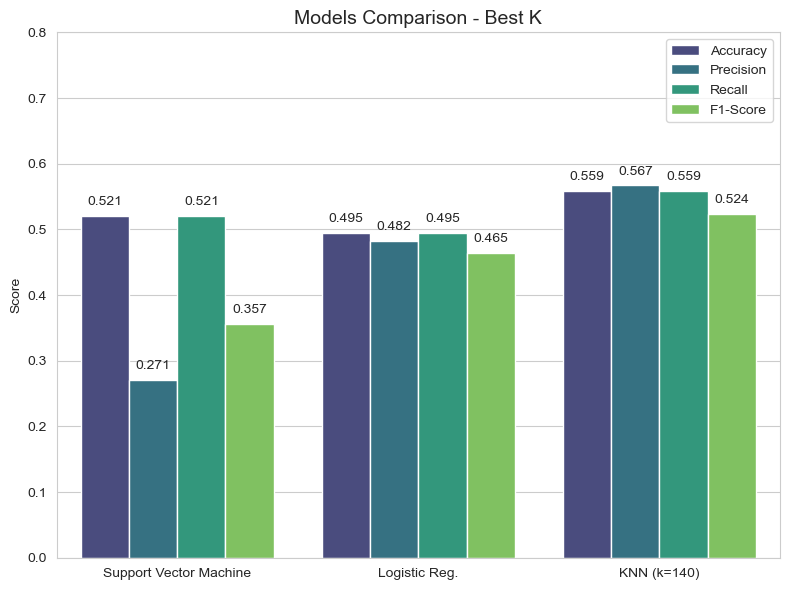

In [21]:
# ===== Models Comparison =====

# Extract Metrics for Each Model
def get_metrics(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# SVM Metrics
svm_pred = clf.predict(test_set)
svm_metrics = get_metrics(test_labels, svm_pred, 'SVM')

# Logistic Regression Metrics
logreg_pred = log_regress.predict(test_set)
logreg_metrics = get_metrics(test_labels, logreg_pred, 'Logistic Regression')

# KNN Metrics
knn_pred = knn.predict(test_set)
knn_metrics = get_metrics(test_labels, knn_pred, f'KNN (k={max_k})')

# Store in DataFrame
metrics_df = pd.DataFrame([svm_metrics, logreg_metrics, knn_metrics])

# ===== Customize X-axis Labels =====
model_labels = {
    'SVM': 'Support Vector Machine',  # Replace with desired label
    'Logistic Regression': 'Logistic Reg.',  # Shortened label
    f'KNN (k={max_k})': f'KNN (k={max_k})'   # Keep as-is or modify
}

# Apply custom labels
metrics_df['Model'] = metrics_df['Model'].map(model_labels)

# ===== Plotting =====
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Melt DataFrame for seaborn
melted_df = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Bar Plot
ax = sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Models Comparison - Best K', fontsize=14)
plt.ylim(0, 0.8)

# Remove x-axis label
ax.set_xlabel('')

# Remove 0.000 annotations (filter out near-zero values)
for p in ax.patches:
    if p.get_height() > 0.001:  # Only label bars with height > 0.001
        ax.annotate(
            f"{p.get_height():.3f}", 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', 
            va='center', 
            xytext=(0, 10), 
            textcoords='offset points'
        )

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()